In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from IPython.display import display, Math, Latex
from scipy.fft import fft, ifft
import scipy.special as sp
import scipy.optimize 
import matplotlib.ticker as ticker
import cmath

Fix:
0. Turn into code and add a ReadMe
1. Make params input dict sensitive -- later
2. Fix detuning term for eta normalizations -- URGENT
3. DPA still needs parameter input, if someone just puts 0, it won't work
4. Fix plot labels -- DONE
5. Change curve styles: dashed, dot-dashed etc. -- later
6. For $\gamma>0$, need to add G_DPA with no gamma for x-axis, but also do not compute it twice for no loss case -- DONE
7. Note: Efficiency is only for lossless case


Check:
1. Different parameters (not so ideal, see if physics changes)
2. Detuning
3. Extra noise

In [2]:
Delta, w, kappa, drive, theta, phi, n_levels, step = 0, 0, 300e6*2*np.pi, 0.2, -np.pi/2, 0, 150, 30 
#no detuning w0 - wp/2, ws-wp/2, cavity decay rate, probe amplitude, drive phase, signal phase, n_levels, # of elements for drive sweep

In [3]:
def _quadratures_from_a(a_c):
    X = (a_c + np.conj(a_c)) / np.sqrt(2)
    P = 1j * (-a_c + np.conj(a_c)) / np.sqrt(2)
    return X, P

def _gain_matrix_from_two_probes(a_out1, a_in1, a_out2, a_in2):
    Xo1, Po1 = _quadratures_from_a(a_out1)
    Xi1, Pi1 = _quadratures_from_a(a_in1)

    Xo2, Po2 = _quadratures_from_a(a_out2)
    Xi2, Pi2 = _quadratures_from_a(a_in2)

    IN  = np.array([[Xi1, Xi2],
                    [Pi1, Pi2]], dtype=complex)
    OUT = np.array([[Xo1, Xo2],
                    [Po1, Po2]], dtype=complex)

    return OUT @ np.linalg.inv(IN)

def _phase_preserving_gain_from_g(g):
    return 0.25 * np.abs(g[0,0] + g[1,1] + 1j*(g[1,0] - g[0,1]))**2

In [4]:
def _solve_two_probes_and_get_g(H0, a, kappa, drive, phi, c_ops):
    """
    Two steady-state solves:
      probe1: epsilon
      probe2: i*epsilon
    """
    def solve_for_epsilon(eps):
        a_in = 1j * eps / np.sqrt(kappa)   # bare kappa
        H_probe = eps * a.dag() + np.conj(eps) * a
        rho_ss = qt.steadystate(H0 + H_probe, c_ops)
        a_exp = qt.expect(a, rho_ss)
        a_out = np.sqrt(kappa) * a_exp + a_in  # bare kappa
        return a_out, a_in

    eps1 = drive * kappa * np.exp(-1j * phi)
    eps2 = drive * kappa * 1j * np.exp(-1j * phi)

    a_out1, a_in1 = solve_for_epsilon(eps1)
    a_out2, a_in2 = solve_for_epsilon(eps2)

    g = _gain_matrix_from_two_probes(a_out1, a_in1, a_out2, a_in2)
    G_lin = _phase_preserving_gain_from_g(g)
    return g, G_lin, eps1

In [5]:
def _vacuum_variance(op, n_levels):
    vac = qt.basis(n_levels, 0)
    exp1 = 0.5 * qt.expect(op.dag()*op + op*op.dag(), vac)
    exp2 = np.abs(qt.expect(op, vac))**2
    return exp1 - exp2

In [6]:
def jpa_params(F_JPA, EC_J, EJ):
    phi_zpf_JPA = (2*EC_J/EJ)**0.25
    ratio = phi_zpf_JPA**2/6
    Kerr = -EC_J * np.cos(F_JPA) / 2
    return ratio, Kerr, phi_zpf_JPA

def STS_params(EC, EL):
    phi_zps = (2*EC/EL)**0.25
    ratio = phi_zps**2/6
    return ratio, phi_zps

In [7]:
def parametric_metrics(
    kind,
    Delta, kappa, gamma, lam, drive, n_levels, theta, phi,
    Kerr=0.0, ratio=0.0
):
    a = qt.destroy(n_levels)

    # gamma ONLY here:
    kappa_eff = kappa + gamma
    c_ops = [np.sqrt(kappa_eff) * a]

    # Quadratic DPA Hamiltonian
    lam_phase = lam * np.exp(-1j * theta)
    H_DPA = (Delta * a.dag() * a
             + (lam_phase/2) * a.dag()*a.dag()
             + (np.conj(lam_phase)/2) * a*a)

    # Nonlinear terms
    H_nl = 0
    if kind.upper() == "DPA":
        LAM = 0.0

    elif kind.upper() == "JPA":
        LAM = -ratio * lam
        H_nl = (Kerr * a.dag()*a.dag()*a*a
                + LAM * (a.dag()*a.dag()*a.dag()*a + a.dag()*a*a*a))

    elif kind.upper() == "STS":
        LAM = -ratio * lam
        H_nl = (LAM * (a.dag()*a.dag()*a.dag()*a + a.dag()*a*a*a))

    else:
        raise ValueError("kind must be one of: 'DPA', 'JPA', 'STS'")

    H0 = H_DPA + H_nl

    # Gain (linear)
    g, G_lin, epsilon = _solve_two_probes_and_get_g(H0, a, kappa, drive, phi, c_ops)

    # Convenience: dB gain (DO NOT use for physics formulas)
    G_dB = 10.0 * np.log10(G_lin) if np.real(G_lin) > 0 else np.nan

    # Coefficient normalization (use linear gain)
    """This is missing detuning Delta, add appropriate terms here"""
    if kind.upper() == "DPA":
        Coeff = kappa/4 + (lam**2)/kappa
    else:
        gsw = cmath.sqrt(G_lin)
        lam_DPA = 1j * kappa * cmath.sqrt(-1 + gsw) / cmath.sqrt(-4 - 4*gsw)
        Coeff = kappa/4 + (np.abs(lam_DPA)**2)/kappa

    # ain_dag (gamma does NOT enter)
    base = ((-1j*Delta + kappa/2)*a.dag()
            - 1j*np.conj(lam_phase)*a)/np.sqrt(kappa) \
           - 1j*np.conj(epsilon)/np.sqrt(kappa)

    if kind.upper() == "DPA":
        ain_dag = base

    elif kind.upper() == "JPA":
        ain_dag = base \
            - 1j*2*Kerr*a.dag()*a.dag()*a/np.sqrt(kappa) \
            - 1j*LAM*(a.dag()*a.dag()*a.dag() + 3*a.dag()*a*a)/np.sqrt(kappa)

    elif kind.upper() == "STS":
        ain_dag = base \
            + 1j*LAM*(a.dag()*a.dag()*a.dag() + 3*a.dag()*a*a)/np.sqrt(kappa)

    var_aindag = _vacuum_variance(ain_dag, n_levels)

    F = (G_lin - 1) * var_aindag / G_lin
    F_norm = F / Coeff
    eta = 1 / (1 + 2*F_norm)

    # Return BOTH gains: linear for physics, dB for plotting
    return g, G_lin, G_dB, F_norm, eta


Parameters, JPA Kerrs in descending order

In [8]:
JPA1_subpar = (np.pi/4, 5*85e5*2*np.pi, 2000e9*2*np.pi)
JPA2_subpar = (np.pi/4, 85e5*2*np.pi, 1900e9*2*np.pi)
JPA3_subpar = (np.pi/4, 85e4*2*np.pi, 2000e9*2*np.pi)
STS_subpar = (48e5*2*np.pi, 1650e9*2*np.pi)

In [9]:
JPA1_par = jpa_params(*JPA1_subpar)
JPA1_ratio, JPA1_Kerr, JPA1_zpf = JPA1_par
# middle Kerr
JPA2_par = jpa_params(*JPA2_subpar)
JPA2_ratio, JPA2_Kerr, JPA2_zpf = JPA2_par
#lowest Kerr
JPA3_par = jpa_params(*JPA3_subpar)
JPA3_ratio, JPA3_Kerr, JPA3_zpf = JPA3_par
STS_par = STS_params(*STS_subpar)
STS_ratio, STS_zpf = STS_par

In [10]:
def _lam_sweep(kappa, span_factor, npts):
    return -np.linspace(0.0, span_factor, npts) * (kappa / 4.0)

In [11]:
lams = _lam_sweep(kappa, 1.95, step)
lams2 = _lam_sweep(kappa, 3.93, step)

Determine $\lambda$ sweep range for given amplifier. Amplifiers with large Kerr need larger drives to be compared with better amplifiers around 20+ dB level. This code gives $\lambda_{max}/4\kappa$.

Make this sensitive to numbers only, and lam conditions don't care about parameters for DPA and STS

In [12]:
def extract_Kerr(kind, params):
    if kind.upper() == "DPA":
        ratio, Kerr, zpf = 0.0, 0.0, 0.0
    
    elif kind.upper() == "JPA":
        if len(params) != 3:
            raise ValueError("jpa_param_sets must be a list of 3 dicts.")
        else: 
            ratio, Kerr, zpf = jpa_params(*params)
    
    elif kind.upper() == "STS":
        Kerr = 0.0
        if len(params) != 2:
            raise ValueError("jpa_param_sets must be a list of 2 dicts.")
        else:
            ratio, zpf = STS_params(*params)
        
    
    else:
        raise ValueError("kind must be one of: 'DPA', 'JPA', 'STS'")

    return ratio, Kerr, zpf
    

New code fix

In [13]:
def _lam_conditions(kind, params, kappa, npts):
    if kind.upper() == "DPA":
        ratio, Kerr, zpf = extract_Kerr("DPA", params)
        lam_max = 1.93
        return _lam_sweep(kappa, lam_max, npts)
    elif kind.upper() == "JPA":
        ratio, Kerr, zpf = extract_Kerr("JPA", params)
        if np.abs(Kerr/kappa) <= 0.01:
            lam_max = 1.93
            return _lam_sweep(kappa, lam_max, npts)
        else:
            lam_max1 = 1.93
            lam_max2 = 3.93
            return _lam_sweep(kappa, lam_max1, npts), _lam_sweep(kappa, lam_max2, npts)
            
        
    elif kind.upper() == "STS":
        ratio, Kerr, zpf = extract_Kerr("STS", params)
        lam_max = 1.93
        return _lam_sweep(kappa, lam_max, npts)  
        
    else:
        raise ValueError("kind must be one of: 'DPA', 'JPA', 'STS'")

In [14]:
def _sweep_G_eta(kind, params, npts, Delta, kappa, gamma, drive, n_levels,
                theta, phi):
    ratio, Kerr, zpf = extract_Kerr(kind, params)
    if kind.upper() == "JPA" and np.abs(Kerr/kappa) > 0.01:
        lamsG, lams_eta = _lam_conditions(kind, params, kappa, npts)
        # Gain for gain plot
        G_g = np.full(len(lamsG), np.nan, dtype=float)
        G_eta = np.full(len(lams_eta), np.nan, dtype=float)
        # Gain and efficiency plot
        eta = np.full(len(lams_eta), np.nan, dtype=float)
        for i, lam in enumerate(lamsG):
            _, _, G_g[i], _, _ = parametric_metrics(
            kind, Delta, kappa, gamma, lam, drive, n_levels, theta, phi,
            Kerr, ratio
            )
        for i, lam in enumerate(lams_eta):
            _, _, G_eta[i], _, eta[i] = parametric_metrics(
            kind, Delta, kappa, gamma, lam, drive, n_levels, theta, phi,
            Kerr, ratio
            )
        return G_g, G_eta, eta
    else:
        lams = _lam_conditions(kind, params, kappa, npts)
        G = np.full(len(lams), np.nan, dtype=float)
        eta = np.full(len(lams), np.nan, dtype=float)
        for i, lam in enumerate(lams):
            _, _, G[i], _, eta[i] = parametric_metrics(
            kind, Delta, kappa, gamma, lam, drive, n_levels, theta, phi,
            Kerr, ratio
    )
        return G, G, eta

In [18]:
def plot_gain_and_efficiency_sweeps_separate(
    # common sim params
    parDPA, parSTS, parJPA1, parJPA2, parJPA3, Delta, kappa, gamma, 
    drive, n_levels, theta, phi,
    # sweep controls
    npts,
    figsize=(12, 5),
):
    
    gain_curves = []  # (label, G_design_gain)
    eta_curves = []  # (label, eta_design_gain)
    #Reminder: DPA works with any parameter entry, but has to be (...,...,...). 
    if gamma != 0.0:
        G_x, _, _ = _sweep_G_eta("DPA", parDPA, npts, Delta, kappa, 0.0, 
                            drive, n_levels, theta, phi)
    
    G_DPA, _, eta_DPA = _sweep_G_eta("DPA", parDPA, npts, Delta, kappa, gamma, 
                    drive, n_levels, theta, phi)
    gain_curves.append(("DPA", G_DPA))
    eta_curves.append(("DPA", G_DPA, eta_DPA))

    G_STS, _, eta_STS = _sweep_G_eta("STS", parSTS, npts, Delta, kappa, gamma, 
                    drive, n_levels, theta, phi)
    gain_curves.append(("STS", G_STS))
    eta_curves.append(("STS", G_STS, eta_STS))

    Gg_JPA1, G_eta_JPA1, eta_JPA1 = _sweep_G_eta("JPA", parJPA1, npts, Delta, kappa, gamma, 
                        drive, n_levels, theta, phi)
    gain_curves.append(("JPA1", Gg_JPA1))
    eta_curves.append(("JPA1", G_eta_JPA1, eta_JPA1))

    Gg_JPA2, G_eta_JPA2, eta_JPA2 = _sweep_G_eta("JPA", parJPA2, npts, Delta, kappa, gamma, 
                            drive, n_levels, theta, phi)
    gain_curves.append(("JPA2", Gg_JPA2))
    eta_curves.append(("JPA2", G_eta_JPA2, eta_JPA2))
    
    Gg_JPA3, G_eta_JPA3, eta_JPA3 = _sweep_G_eta("JPA", parJPA3, npts, Delta, kappa, gamma, 
                            drive, n_levels, theta, phi)
    gain_curves.append(("JPA3", Gg_JPA3))
    eta_curves.append(("JPA3", G_eta_JPA3, eta_JPA3))

    # Plotting
        # =========================
    if gamma != 0.0:
        fig, ax1 = plt.subplots(figsize=(6,4))
        ax2 = None
        x = G_x
        
    else:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
        x = G_DPA

    #print("FIG ID:", id(fig), "FIGNUM:", fig.number)
    for label, y in gain_curves:
        ax1.plot(x, y, lw=2, label=label)

    ax1.set_xlabel(r"DPA phase-preserving gain $G_{\mathrm{DPA}}$ (dB), $\gamma=0$")
    ax1.set_ylabel(r"Design phase-preserving gain $G$ (dB)")
    ax1.set_title(fr"Gain comparison ($\gamma/\kappa$ = {(gamma/kappa):.2g})")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Plot 2 (only if it exists)
    if ax2 is not None:
        for label, G, eta in eta_curves:
            ax2.plot(G, eta, lw=2, label=label)

        ax2.set_xlabel(r"Phase-preserving gain $G$ (dB)")
        ax2.set_ylabel(r"Quantum efficiency $\eta$")
        ax2.set_title(r"Efficiency vs Gain $\gamma=0$")
        ax2.set_ylim(-0.05, 1.05)
        ax2.set_xlim(0.0, 25.0)
        ax2.grid(True, alpha=0.3)
        ax2.legend()

    plt.tight_layout()

    return fig

In [ ]:
plot_gain_and_efficiency_sweeps_separate(
    # common sim params
    STS_subpar, STS_subpar, JPA1_subpar, JPA2_subpar, JPA3_subpar, Delta, kappa, 0.0, 
    drive, n_levels, theta, phi,
    # sweep controls
    step,
    figsize=(12, 5),
)

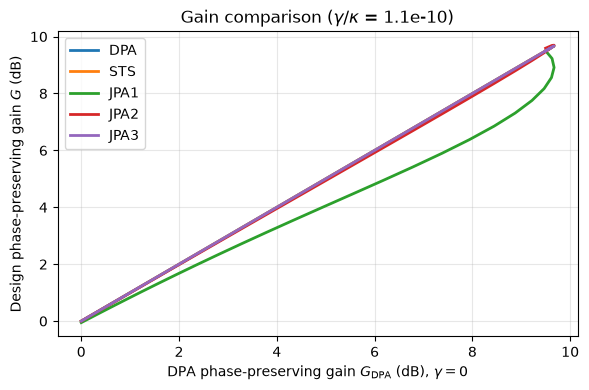

In [19]:
fig1 = plot_gain_and_efficiency_sweeps_separate(
    # common sim params
    STS_subpar, STS_subpar, JPA1_subpar, JPA2_subpar, JPA3_subpar, Delta, kappa, 0.2, 
    drive, 10, theta, phi,
    # sweep controls
    step,
    figsize=(12, 5),
)

In [ ]:
plot_gain_and_efficiency_sweeps_separate(
    # common sim params
    STS_subpar, STS_subpar, JPA1_subpar, JPA2_subpar, JPA3_subpar, Delta, kappa, 0.05 * kappa, 
    drive, n_levels, theta, phi,
    # sweep controls
    step,
    figsize=(12, 5),
)

In [ ]:
plot_gain_and_efficiency_sweeps_separate(
    # common sim params
    STS_subpar, STS_subpar, JPA1_subpar, JPA2_subpar, JPA3_subpar, Delta, kappa, 0.0, 
    drive, n_levels, theta, phi,
    # sweep controls
    step,
    figsize=(12, 5),
)

End of code ---

In [ ]:
G_DPA = np.full(len(lams), np.nan, dtype=float)
eta_DPA = np.full(len(lams), np.nan, dtype=float)
for i, lam in enumerate(lams):
    _, _, G_DPA[i], _, eta_DPA[i] = parametric_metrics(
    "DPA",
    Delta, kappa, 0.0, lam, drive, n_levels, theta, phi,
    Kerr=0.0, ratio=0.0
)

In [ ]:
G_JPA1 = np.full(len(lams2), np.nan, dtype=float)
eta_JPA1 = np.full(len(lams2), np.nan, dtype=float)
for i, lam in enumerate(lams2):
    _, _, G_JPA1[i], _, eta_JPA1[i] = parametric_metrics(
    "JPA",
    Delta, kappa, 0.0, lam, drive, n_levels, theta, phi,
    Kerr=JPA1_Kerr, ratio=JPA1_ratio
)

In [ ]:
G_JPA3 = np.full(len(lams), np.nan, dtype=float)
eta_JPA3 = np.full(len(lams), np.nan, dtype=float)
for i, lam in enumerate(lams):
    _, _, G_JPA3[i], _, eta_JPA3[i] = parametric_metrics(
    "JPA",
    Delta, kappa, 0.0, lam, drive, n_levels, theta, phi,
    Kerr=JPA3_Kerr, ratio=JPA3_ratio
)

In [ ]:
G_STS = np.full(len(lams), np.nan, dtype=float)
eta_STS = np.full(len(lams), np.nan, dtype=float)
for i, lam in enumerate(lams):
    _, _, G_STS[i], _, eta_STS[i] = parametric_metrics(
    "STS",
    Delta, kappa, 0.0, lam, drive, n_levels, theta, phi,
    Kerr=0.0, ratio=STS_ratio
)

In [ ]:
G_JPA1

In [ ]:
eta_JPA1